In [1]:
import pandas as pd
from pathlib import Path
import subprocess
import sys
import os
results_folders = ["../WMSE", "../WMSLE", "../ZINB"]
combined_df = pd.DataFrame()

for results_folder in results_folders:
    folder = Path(results_folder)

    # 1) build filtered file by executing the script
    subprocess.run(
        [sys.executable, "../create_complete_df.py", "-f", str(folder)],
        check=True,
    )
    # load pkl file
    temp_df = pd.read_pickle(os.path.join(results_folder, "filtered_results.pkl"))
    temp_df["loss"] = results_folder.split("/")[-1]
    combined_df = pd.concat([combined_df, temp_df], ignore_index=True)


Total number of rows in the combined DataFrame: 2160
Original group sizes:
20    108
Name: count, dtype: int64

✓ All original groups have exactly 20 rows
After filtering (top 25%), each group will have 5 rows

Total number of unique combinations: 108
Total number of rows in the filtered DataFrame: 540 from the total of 2160
Filtered results saved to: /home/biazzin/git/AIedes/experiments/counter/results/WMSE/filtered_results.pkl
Filtered DataFrame shape: (540, 73)
Filtered DataFrame columns: ['model_type', 'loss_type', 'hidden_dim', 'num_layers', 'dropout', 'num_epochs', 'learning_rate', 'batch_size', 'random_state', 'nonzero_weight', 'num_heads', 'command_line_params', 'num_params', 'input_variables', 'train_loss', 'test_loss', 'train_r2', 'test_r2', 'train_rmse', 'test_rmse', 'train_pearson_r2', 'test_pearson_r2', 'train_slope', 'test_slope', 'train_intercept', 'test_intercept', 'train_log_r2', 'test_log_r2', 'train_log_slope', 'test_log_slope', 'train_log_intercept', 'test_log_inter

len(combined_df["train_r2"].unique())

In [2]:
combined_df["input_variables"].unique()

array(['p1zn; p2zn',
       't2m_mean_znorm; d2m_mean_znorm; tp_sum_znorm; p1zn; p2zn',
       't2m_mean_znorm; d2m_mean_znorm; tp_sum_znorm',
       't2m_mean_znorm(mean); d2m_mean_znorm(mean); tp_sum_znorm(mean); p1zn; p2zn',
       't2m_mean_znorm(mean); d2m_mean_znorm(mean); tp_sum_znorm(mean)',
       't2m_mean_znorm(mean); tp_sum_znorm(mean); p1zn; p2zn',
       't2m_mean_znorm(mean); tp_sum_znorm(mean)',
       't2m_mean_znorm; tp_sum_znorm; p1zn; p2zn',
       't2m_mean_znorm; tp_sum_znorm'], dtype=object)

In [3]:
combined_df.keys()

Index(['model_type', 'loss_type', 'hidden_dim', 'num_layers', 'dropout',
       'num_epochs', 'learning_rate', 'batch_size', 'random_state',
       'nonzero_weight', 'num_heads', 'command_line_params', 'num_params',
       'input_variables', 'train_loss', 'test_loss', 'train_r2', 'test_r2',
       'train_rmse', 'test_rmse', 'train_pearson_r2', 'test_pearson_r2',
       'train_slope', 'test_slope', 'train_intercept', 'test_intercept',
       'train_log_r2', 'test_log_r2', 'train_log_slope', 'test_log_slope',
       'train_log_intercept', 'test_log_intercept', 'train_nonzero_r2',
       'test_nonzero_r2', 'train_nonzero_slope', 'test_nonzero_slope',
       'train_nonzero_intercept', 'test_nonzero_intercept',
       'train_binary_accuracy', 'test_binary_accuracy', 'train_FPR',
       'test_FPR', 'train_FNR', 'test_FNR', 'train_TPR', 'test_TPR',
       'train_TNR', 'test_TNR', 'train_data', 'test_data', 'train_targets',
       'test_targets', 'source_file', 'train_loss_end', 'test_loss_end

In [4]:
# Define variable names that can be easily changed
T2M = r'$AT_{90d}$'
T2M_WK = r'$AT_{13w}$'
T2M_MO = r'$T2M^{mo}$'
TP = r'$TP_{90d}$'
TP_WK = r'$TP_{13w}$'
D2M = r'$DP_{90d}$'
D2M_W = r'$DP_{13w}$'
R_T1 = r'$R_{t-1}$'
R_T2 = r'$R_{t-2}$'
ELR_WK = r'$ER_{2w}$'

# Create a mapping for cleaner variable names using the defined variables
variable_name_mapping = {
    'p1zn; p2zn': f'{ELR_WK}',    
    't2m_mean_znorm; tp_sum_znorm': f'{T2M} + {TP}',
    't2m_mean_znorm(mean); tp_sum_znorm(mean)': f'{T2M_WK} + {TP_WK}',
    't2m_mean_znorm; tp_sum_znorm; p1zn; p2zn': f'{T2M} + {TP} + {ELR_WK}',
    't2m_mean_znorm(mean); tp_sum_znorm(mean); p1zn; p2zn': f'{T2M_WK} + {TP_WK} + {ELR_WK}',
    't2m_mean_znorm; d2m_mean_znorm; tp_sum_znorm': f'{T2M} + {TP} + {D2M}',
    't2m_mean_znorm(mean); d2m_mean_znorm(mean); tp_sum_znorm(mean)': f'{T2M_WK} + {TP_WK} + {D2M_W}',
    't2m_mean_znorm; d2m_mean_znorm; tp_sum_znorm; p1zn; p2zn': f'{T2M} + {TP} + {D2M} + {ELR_WK}',
    't2m_mean_znorm(mean); d2m_mean_znorm(mean); tp_sum_znorm(mean); p1zn; p2zn': f'{T2M_WK} + {TP_WK} + {D2M_W} + {ELR_WK}',
}
# check if all input variables are in the mapping and if not print the missing ones
for input_var in combined_df["input_variables"].unique():
    if input_var not in variable_name_mapping:
        print(f"Missing mapping for: {input_var}")
# Apply the mapping to your dataframe
combined_df['input_variables_clean'] = combined_df['input_variables'].map(variable_name_mapping)

# Define custom order for input variables using the defined variables
desired_order = [
    f'{ELR_WK}', 
    f'{T2M} + {TP}',
    f'{T2M_WK} + {TP_WK}',
    f'{T2M} + {TP} + {ELR_WK}',
    f'{T2M_WK} + {TP_WK} + {ELR_WK}',
    f'{T2M} + {TP} + {D2M}',
    f'{T2M_WK} + {TP_WK} + {D2M_W}',
    f'{T2M} + {TP} + {D2M} + {ELR_WK}',
    f'{T2M_WK} + {TP_WK} + {D2M_W} + {ELR_WK}',

]



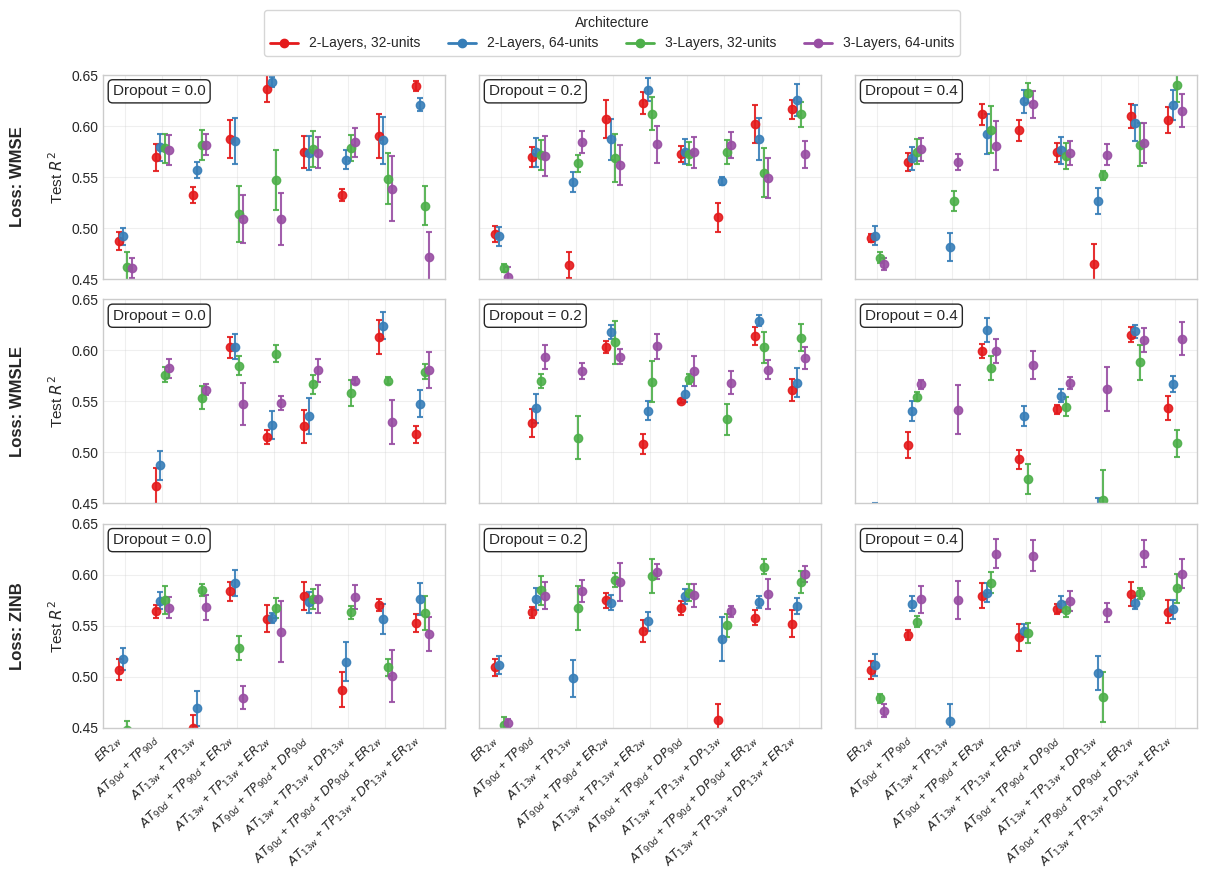

Saved: ./nn_results_by_dropout_3loss.pdf


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# --- styling ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# --- pick losses (rows) ---
loss_row_order = sorted(combined_df["loss"].dropna().unique().tolist())  # keep all present

# --- precompute grouped stats per loss ---
def build_group(df):
    g = (
        df.groupby(['dropout', 'input_variables_clean', 'num_layers', 'hidden_dim'])['test_r2']
          .agg(mean='mean', sem='sem')
          .reset_index()
    )
    return g[g['input_variables_clean'].isin(desired_order)]

grouped_by_loss = {L: build_group(combined_df[combined_df['loss'] == L]) for L in loss_row_order}

# --- figure layout: rows=losses, cols=union of dropouts ---
dropouts_union = sorted(pd.unique(pd.concat(
    [g['dropout'] for g in grouped_by_loss.values() if not g.empty],
    ignore_index=True
))) if any(not g.empty for g in grouped_by_loss.values()) else []

if not dropouts_union:
    raise ValueError("No data available after grouping/filtering.")

nrows, ncol = len(loss_row_order), len(dropouts_union)
fig, axes = plt.subplots(nrows, ncol, sharey=True, figsize=(4*ncol, 3*nrows))
if nrows == 1 and ncol == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes[np.newaxis, :]
elif ncol == 1:
    axes = axes[:, np.newaxis]

# --- color map is global: same (layers,dim) color everywhere ---
all_combos = pd.concat(
    [g[['num_layers','hidden_dim']] for g in grouped_by_loss.values() if not g.empty],
    ignore_index=True
).drop_duplicates().sort_values(['num_layers','hidden_dim']).to_records(index=False).tolist()

palette = sns.color_palette("Set1", n_colors=max(4, len(all_combos)))
combo2color = {combo: palette[i % len(palette)] for i, combo in enumerate(all_combos)}

# --- plotting ---
for r, loss_name in enumerate(loss_row_order):
    g = grouped_by_loss[loss_name]
    if g.empty:
        for c in range(ncol):
            ax = axes[r, c]
            ax.text(0.5, 0.5, f"No data for loss = {loss_name}", ha='center', va='center')
            ax.set_axis_off()
        continue

    # row label
    axes[r, 0].text(-0.25, 0.5, f"Loss: {loss_name}", transform=axes[r, 0].transAxes,
                    rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')

    for c, do in enumerate(dropouts_union):
        ax = axes[r, c]
        sub = g[g['dropout'] == do]
        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', fontsize=10)
            ax.set_axis_off()
            continue

        # fixed x order by desired_order
        order_map = {v: i for i, v in enumerate(desired_order)}
        # which architecture combos present in this cell (for offsets)
        combos_here = sub.groupby(['num_layers','hidden_dim']).size().index.tolist()
        n_groups = len(combos_here)

        # plot each (layers,dim)
        for i, (layers, dim) in enumerate(combos_here):
            sub2 = sub[(sub['num_layers']==layers) & (sub['hidden_dim']==dim)].copy()
            sub2['xorder'] = sub2['input_variables_clean'].map(order_map)
            sub2 = sub2.sort_values('xorder')

            # small horizontal displacement per group
            disp = (i - (n_groups - 1) / 2) * 0.12
            x = np.arange(len(sub2)) + disp

            ax.errorbar(
                x, sub2['mean'], yerr=sub2['sem'],
                fmt='o',  # just points, no line
                markersize=6, capsize=2, capthick=1.5, alpha=0.9,
                color=combo2color[(layers, dim)],
                label=f"{layers}-Layers, {dim}-units"
            )

        # x ticks (only on last row)
        labels_here = [lab for lab in desired_order if lab in sub['input_variables_clean'].unique()]
        if r == nrows - 1:
            ax.set_xticks(np.arange(len(labels_here)))
            ax.set_xticklabels(labels_here, rotation=45, ha='right', fontsize=9)
        else:
            ax.set_xticks(np.arange(len(labels_here)))
            ax.set_xticklabels([])

        # y label only on first column
        if c == 0:
            ax.set_ylabel(r'Test $R^2$', fontsize=11)

        # small panel title (dropout)
        ax.text(0.3, 0.92, f"Dropout = {do:.1f}", transform=ax.transAxes, fontsize=11,
                ha='right', va='center',
                bbox=dict(boxstyle="round,pad=0.3", edgecolor='black',
                          facecolor='white', alpha=0.85))

        ax.grid(True, alpha=0.3)

# --- single, correct legend with ALL architectures ---
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='-', linewidth=2,
           label=f"{layers}-Layers, {dim}-units",
           color=combo2color[(layers, dim)])
    for (layers, dim) in all_combos
]
fig.legend(legend_handles, [h.get_label() for h in legend_handles],
           loc='upper center', bbox_to_anchor=(0.5, 0.98),
           ncol=min(len(legend_handles), 5), frameon=True, fancybox=True, title="Architecture")

# --- global limits & layout ---
plt.ylim(0.45, 0.65)  # adjust if needed
plt.tight_layout()
plt.subplots_adjust(top=0.90, wspace=0.1, hspace=0.10)

outpath = "./nn_results_by_dropout_3loss.pdf"
plt.savefig(outpath, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {outpath}")


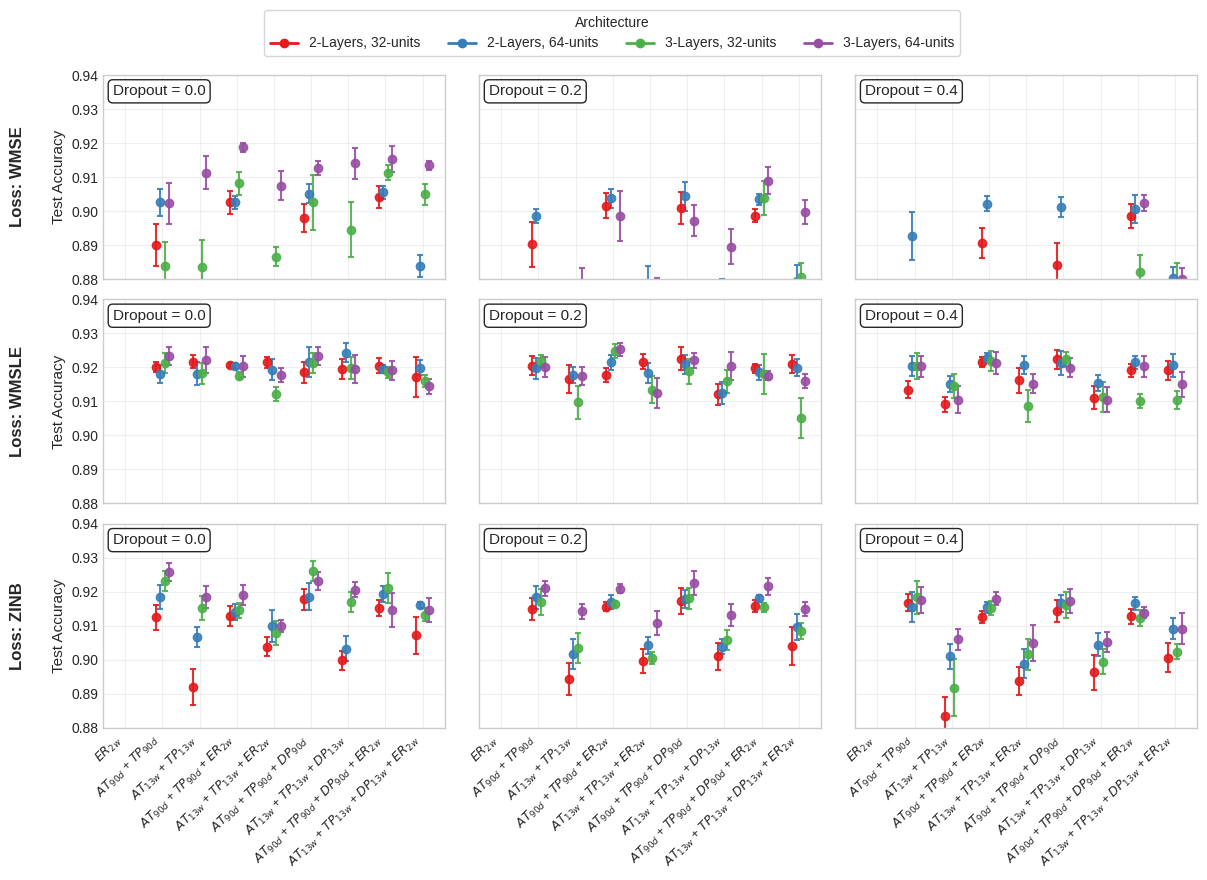

Saved: ./nn_results_by_dropout_3loss_acc.pdf


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

# --- styling ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# --- pick losses (rows) ---
loss_row_order = sorted(combined_df["loss"].dropna().unique().tolist())  # keep all present

# --- precompute grouped stats per loss ---
def build_group(df):
    g = (
        df.groupby(['dropout', 'input_variables_clean', 'num_layers', 'hidden_dim'])['test_binary_accuracy']
          .agg(mean='mean', sem='sem')
          .reset_index()
    )
    return g[g['input_variables_clean'].isin(desired_order)]

grouped_by_loss = {L: build_group(combined_df[combined_df['loss'] == L]) for L in loss_row_order}

# --- figure layout: rows=losses, cols=union of dropouts ---
dropouts_union = sorted(pd.unique(pd.concat(
    [g['dropout'] for g in grouped_by_loss.values() if not g.empty],
    ignore_index=True
))) if any(not g.empty for g in grouped_by_loss.values()) else []

if not dropouts_union:
    raise ValueError("No data available after grouping/filtering.")

nrows, ncol = len(loss_row_order), len(dropouts_union)
fig, axes = plt.subplots(nrows, ncol, sharey=True, figsize=(4*ncol, 3*nrows))
if nrows == 1 and ncol == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes[np.newaxis, :]
elif ncol == 1:
    axes = axes[:, np.newaxis]

# --- color map is global: same (layers,dim) color everywhere ---
all_combos = pd.concat(
    [g[['num_layers','hidden_dim']] for g in grouped_by_loss.values() if not g.empty],
    ignore_index=True
).drop_duplicates().sort_values(['num_layers','hidden_dim']).to_records(index=False).tolist()

palette = sns.color_palette("Set1", n_colors=max(4, len(all_combos)))
combo2color = {combo: palette[i % len(palette)] for i, combo in enumerate(all_combos)}

# --- plotting ---
for r, loss_name in enumerate(loss_row_order):
    g = grouped_by_loss[loss_name]
    if g.empty:
        for c in range(ncol):
            ax = axes[r, c]
            ax.text(0.5, 0.5, f"No data for loss = {loss_name}", ha='center', va='center')
            ax.set_axis_off()
        continue

    # row label
    axes[r, 0].text(-0.25, 0.5, f"Loss: {loss_name}", transform=axes[r, 0].transAxes,
                    rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')

    for c, do in enumerate(dropouts_union):
        ax = axes[r, c]
        sub = g[g['dropout'] == do]
        if sub.empty:
            ax.text(0.5, 0.5, "No data", ha='center', va='center', fontsize=10)
            ax.set_axis_off()
            continue

        # fixed x order by desired_order
        order_map = {v: i for i, v in enumerate(desired_order)}
        # which architecture combos present in this cell (for offsets)
        combos_here = sub.groupby(['num_layers','hidden_dim']).size().index.tolist()
        n_groups = len(combos_here)

        # plot each (layers,dim)
        for i, (layers, dim) in enumerate(combos_here):
            sub2 = sub[(sub['num_layers']==layers) & (sub['hidden_dim']==dim)].copy()
            sub2['xorder'] = sub2['input_variables_clean'].map(order_map)
            sub2 = sub2.sort_values('xorder')

            # small horizontal displacement per group
            disp = (i - (n_groups - 1) / 2) * 0.12
            x = np.arange(len(sub2)) + disp

            ax.errorbar(
                x, sub2['mean'], yerr=sub2['sem'],
                fmt='o',  # just points, no line
                markersize=6, capsize=2, capthick=1.5, alpha=0.9,
                color=combo2color[(layers, dim)],
                label=f"{layers}-Layers, {dim}-units"
            )

        # x ticks (only on last row)
        labels_here = [lab for lab in desired_order if lab in sub['input_variables_clean'].unique()]
        if r == nrows - 1:
            ax.set_xticks(np.arange(len(labels_here)))
            ax.set_xticklabels(labels_here, rotation=45, ha='right', fontsize=9)
        else:
            ax.set_xticks(np.arange(len(labels_here)))
            ax.set_xticklabels([])

        # y label only on first column
        if c == 0:
            ax.set_ylabel(r'Test Accuracy', fontsize=11)

        # small panel title (dropout)
        ax.text(0.3, 0.92, f"Dropout = {do:.1f}", transform=ax.transAxes, fontsize=11,
                ha='right', va='center',
                bbox=dict(boxstyle="round,pad=0.3", edgecolor='black',
                          facecolor='white', alpha=0.85))

        ax.grid(True, alpha=0.3)

# --- single, correct legend with ALL architectures ---
legend_handles = [
    Line2D([0], [0], marker='o', linestyle='-', linewidth=2,
           label=f"{layers}-Layers, {dim}-units",
           color=combo2color[(layers, dim)])
    for (layers, dim) in all_combos
]
fig.legend(legend_handles, [h.get_label() for h in legend_handles],
           loc='upper center', bbox_to_anchor=(0.5, 0.98),
           ncol=min(len(legend_handles), 5), frameon=True, fancybox=True, title="Architecture")

# --- global limits & layout ---
plt.ylim(0.88, 0.94)  # adjust if needed
plt.tight_layout()
plt.subplots_adjust(top=0.90, wspace=0.1, hspace=0.10)

outpath = "./nn_results_by_dropout_3loss_acc.pdf"
plt.savefig(outpath, bbox_inches='tight', dpi=300)
plt.show()
print(f"Saved: {outpath}")


In [7]:
import pandas as pd
import numpy as np

# --- 1) Aggregate means & SEMs, now including 'loss' ---
metrics = ['test_r2', 'test_loss', 'test_binary_accuracy', 'test_rmse']
agg_funcs = {m: ['mean', 'sem'] for m in metrics}

summary_df = (
    combined_df
      .groupby(['loss', 'input_variables_clean', 'dropout', 'num_layers', 'hidden_dim'])
      .agg(agg_funcs)
)

# flatten MultiIndex columns
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
summary_df = summary_df.reset_index()

# --- 2) For each loss, choose the best variable set, then the best config within it ---
rows = []
for loss_name, dfL in summary_df.groupby('loss'):
    if dfL.empty:
        continue
    # pick the variable set that can reach the highest mean R^2 with *any* architecture
    perf_by_var = dfL.groupby('input_variables_clean')['test_r2_mean'].max().sort_values(ascending=False)
    best_var = perf_by_var.index[0]

    # within that best variable set, pick the single best configuration
    best_cfg = (dfL[dfL['input_variables_clean'] == best_var]
                .sort_values('test_r2_mean', ascending=False)
                .head(1)
                .copy())
    best_cfg['__loss__'] = loss_name  # keep loss for the output
    rows.append(best_cfg)

if not rows:
    raise ValueError("No data available to build the table.")

best_per_loss = pd.concat(rows, ignore_index=True)

# --- 3) Pretty formatting ---
def fmt_pm(mean, sem, ndigits=3):
    return rf"${mean:.{ndigits}f} \pm {sem:.{ndigits}f}$"

# Replace " + " with \text{+} in LaTeX math mode
best_per_loss['input_variables_clean'] = (
    best_per_loss['input_variables_clean'].str.replace(' + ', r'\,\text{+}\,', regex=False)
)

best_per_loss['R^2']  = [fmt_pm(m, s, 3) for m, s in zip(best_per_loss['test_r2_mean'],              best_per_loss['test_r2_sem'])]
best_per_loss['Loss'] = [fmt_pm(m, s, 3) for m, s in zip(best_per_loss['test_loss_mean'],            best_per_loss['test_loss_sem'])]
best_per_loss['Acc']  = [fmt_pm(m, s, 3) for m, s in zip(best_per_loss['test_binary_accuracy_mean'], best_per_loss['test_binary_accuracy_sem'])]
best_per_loss['RMSE'] = [fmt_pm(m, s, 1) for m, s in zip(best_per_loss['test_rmse_mean'],            best_per_loss['test_rmse_sem'])]

# --- 4) Select & rename columns for LaTeX ---
latex_df = best_per_loss.rename(columns={
    '__loss__': 'LossFn',
    'input_variables_clean': 'Variables',
    'dropout': 'DO',
    'num_layers': 'Lay',
    'hidden_dim': 'HU',
})[['LossFn', 'Variables', 'DO', 'Lay', 'HU', 'R^2', 'Loss', 'Acc', 'RMSE']]

# Sort by R^2 (optional, comment out if you prefer original loss order)
# latex_df = latex_df.sort_values(by='R^2', ascending=False, key=lambda s: best_per_loss['test_r2_mean'])

# --- 5) Emit LaTeX (3 rows, one per loss) ---
print(latex_df.to_latex(
    index=False,
    escape=False,  # keep $...$ and \text{+}
    caption=r"Best configuration per loss, restricted to that loss's top input-variable set (by Test $R^2$).",
    label="tab:best_per_loss",
    column_format='l' + 'l' + 'r'*(latex_df.shape[1]-2)  # LossFn & Variables left, rest right
))


\begin{table}
\caption{Best configuration per loss, restricted to that loss's top input-variable set (by Test $R^2$).}
\label{tab:best_per_loss}
\begin{tabular}{llrrrrrrr}
\toprule
LossFn & Variables & DO & Lay & HU & R^2 & Loss & Acc & RMSE \\
\midrule
WMSE & $AT_{13w}$\,\text{+}\,$TP_{13w}$\,\text{+}\,$ER_{2w}$ & 0.000000 & 2 & 64 & $0.643 \pm 0.005$ & $745.614 \pm 107.991$ & $0.870 \pm 0.005$ & $22.8 \pm 1.5$ \\
WMSLE & $AT_{90d}$\,\text{+}\,$TP_{90d}$\,\text{+}\,$DP_{90d}$\,\text{+}\,$ER_{2w}$ & 0.200000 & 2 & 64 & $0.629 \pm 0.005$ & $0.589 \pm 0.023$ & $0.919 \pm 0.002$ & $22.6 \pm 1.2$ \\
ZINB & $AT_{90d}$\,\text{+}\,$TP_{90d}$\,\text{+}\,$ER_{2w}$ & 0.400000 & 3 & 64 & $0.621 \pm 0.014$ & $1.193 \pm 0.029$ & $0.918 \pm 0.002$ & $23.2 \pm 1.3$ \\
\bottomrule
\end{tabular}
\end{table}



In [8]:
# make pandas show all columns and avoid horizontal cut
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)       # let it expand to your console width
pd.set_option("display.max_colwidth", None)  # don't truncate long strings


In [9]:
import numpy as np
import pandas as pd

# --- choose which 3 losses to show (or set explicitly) ---
loss_values = sorted(combined_df["loss"].dropna().unique().tolist())
loss_row_order = loss_values

# --- config/grouping columns ---
group_cols = ['loss', 'dropout', 'num_layers', 'hidden_dim', 'input_variables_clean']

# --- metrics to include ---
metrics = [
    'test_r2',
    'test_binary_accuracy',
    'test_rmse',
    'test_log_r2',
    'test_nonzero_r2',
    'test_pearson_r2',
]
metrics = [m for m in metrics if m in combined_df.columns]

if 'test_r2' not in metrics:
    raise KeyError("Column 'test_r2' is required for sorting but not found in combined_df.")

# --- aggregate mean/std/sem per configuration ---
df_nonan = combined_df.dropna(subset=['test_r2']).copy()

stats = (
    df_nonan
    .groupby(group_cols)[metrics]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

# flatten MultiIndex
stats.columns = [
    (f"{a}_{b}" if b else a) if isinstance(a, str) else "_".join([str(x) for x in (a, b) if x])
    for a, b in stats.columns
]

# compute SEM
for m in metrics:
    stats[f"{m}_sem"] = stats[f"{m}_std"] / np.sqrt(stats[f"{m}_count"].clip(lower=1))

# reorder columns: configs + test_r2 first
config_cols = group_cols
ordered_metric_cols = []
for m in ['test_r2'] + [m for m in metrics if m != 'test_r2']:
    for suf in ('mean', 'std', 'sem'):
        col = f"{m}_{suf}"
        if col in stats.columns:
            ordered_metric_cols.append(col)

stats = stats[config_cols + ordered_metric_cols]

# --- nice renaming map ---
rename_map = {
    'test_r2_mean': 'R2_mean',
    'test_r2_std': 'R2_std',
    'test_r2_sem': 'R2_sem',
    'test_binary_accuracy_mean': 'Acc_mean',\
    'test_binary_accuracy_std': 'Acc_std',
    'test_binary_accuracy_sem': 'Acc_sem',
    'test_rmse_mean': 'RMSE_mean',
    'test_rmse_std': 'RMSE_std',
    'test_rmse_sem': 'RMSE_sem',
    'test_log_r2_mean': 'LogR2_mean',
    'test_log_r2_std': 'LogR2_std',
    'test_log_r2_sem': 'LogR2_sem',
    'test_nonzero_r2_mean': 'NZ_R2_mean',
    'test_nonzero_r2_std': 'NZ_R2_std',
    'test_nonzero_r2_sem': 'NZ_R2_sem',
    'test_pearson_r2_mean': 'PearsonR2_mean',
    'test_pearson_r2_std': 'PearsonR2_std',
    'test_pearson_r2_sem': 'PearsonR2_sem',
}
stats = stats.rename(columns=rename_map)

# --- helper: top-k per loss (sorted by R2_mean) ---
def top_k_for_loss(loss_name, k=6):
    df = stats[stats['loss'] == loss_name].copy()
    df = df.sort_values('R2_mean', ascending=False).head(k)
    # round numeric columns for readability
    numcols = [c for c in df.columns if c not in config_cols]
    df[numcols] = df[numcols].apply(pd.to_numeric, errors='coerce').round(4)
    return df.drop(columns=['loss'])

# --- build & display ---
top_tables = {loss: top_k_for_loss(loss, k=6) for loss in loss_row_order}

for loss, df in top_tables.items():
    print(f"\nTop 6 configs for loss = {loss} (sorted by R2_mean)")
    display(df)



Top 6 configs for loss = WMSE (sorted by R2_mean)


,dropout,num_layers,hidden_dim,input_variables_clean,R2_mean,R2_std,R2_sem,Acc_mean,Acc_std,Acc_sem,RMSE_mean,RMSE_std,RMSE_sem,LogR2_mean,LogR2_std,LogR2_sem,NZ_R2_mean,NZ_R2_std,NZ_R2_sem,PearsonR2_mean,PearsonR2_std,PearsonR2_sem
12,0.0,2,64,$AT_{13w}$ + $TP_{13w}$ + $ER_{2w}$,0.6431,0.0116,0.0052,0.8696,0.0107,0.0048,22.7710,3.4332,1.5354,0.4671,0.0378,0.0169,0.5703,0.0268,0.0120,0.6511,0.0120,0.0054
92,0.4,3,32,$AT_{13w}$ + $TP_{13w}$ + $DP_{13w}$ + $ER_{2w}$,0.6406,0.0386,0.0173,0.8782,0.0149,0.0066,22.8812,4.1045,1.8356,0.5378,0.0398,0.0178,0.5515,0.0624,0.0279,0.6504,0.0355,0.0159
2,0.0,2,32,$AT_{13w}$ + $TP_{13w}$ + $DP_{13w}$ + $ER_{2w}$,0.6392,0.0111,0.0049,0.8647,0.0146,0.0065,22.2625,2.9408,1.3152,0.4396,0.0577,0.0258,0.5613,0.0330,0.0148,0.6455,0.0078,0.0035
3,0.0,2,32,$AT_{13w}$ + $TP_{13w}$ + $ER_{2w}$,0.6364,0.0296,0.0132,0.8554,0.0174,0.0078,24.2081,4.1390,1.8510,0.4432,0.0607,0.0272,0.5612,0.0464,0.0208,0.6435,0.0210,0.0094
48,0.2,2,64,$AT_{13w}$ + $TP_{13w}$ + $ER_{2w}$,0.6354,0.0251,0.0112,0.8780,0.0133,0.0059,24.2022,3.7527,1.6783,0.4739,0.0474,0.0212,0.5532,0.0447,0.0200,0.6432,0.0187,0.0084
93,0.4,3,32,$AT_{13w}$ + $TP_{13w}$ + $ER_{2w}$,0.6324,0.0221,0.0099,0.8363,0.0518,0.0231,22.4693,3.0885,1.3812,0.4393,0.1125,0.0503,0.5365,0.0362,0.0162,0.6420,0.0306,0.0137



Top 6 configs for loss = WMSLE (sorted by R2_mean)


,dropout,num_layers,hidden_dim,input_variables_clean,R2_mean,R2_std,R2_sem,Acc_mean,Acc_std,Acc_sem,RMSE_mean,RMSE_std,RMSE_sem,LogR2_mean,LogR2_std,LogR2_sem,NZ_R2_mean,NZ_R2_std,NZ_R2_sem,PearsonR2_mean,PearsonR2_std,PearsonR2_sem
159,0.2,2,64,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.6291,0.0123,0.0055,0.9185,0.0050,0.0023,22.5519,2.7840,1.2451,0.6528,0.0169,0.0076,0.5272,0.0248,0.0111,0.6382,0.0162,0.0072
123,0.0,2,64,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.6241,0.0301,0.0135,0.9195,0.0024,0.0011,23.4518,4.3204,1.9322,0.6259,0.0238,0.0107,0.5258,0.0354,0.0158,0.6474,0.0251,0.0112
196,0.4,2,64,$AT_{90d}$ + $TP_{90d}$ + $ER_{2w}$,0.6201,0.0266,0.0119,0.9228,0.0029,0.0013,22.7972,2.7449,1.2276,0.6630,0.0199,0.0089,0.5151,0.0434,0.0194,0.6297,0.0338,0.0151
195,0.4,2,64,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.6187,0.0135,0.0060,0.9214,0.0041,0.0018,22.8690,2.8455,1.2725,0.6560,0.0170,0.0076,0.5120,0.0307,0.0137,0.6258,0.0180,0.0081
160,0.2,2,64,$AT_{90d}$ + $TP_{90d}$ + $ER_{2w}$,0.6182,0.0152,0.0068,0.9214,0.0052,0.0023,22.9128,3.1582,1.4124,0.6500,0.0163,0.0073,0.5131,0.0201,0.0090,0.6338,0.0257,0.0115
186,0.4,2,32,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.6155,0.0157,0.0070,0.9191,0.0044,0.0020,22.9913,3.1715,1.4183,0.6529,0.0255,0.0114,0.5119,0.0271,0.0121,0.6235,0.0180,0.0081



Top 6 configs for loss = ZINB (sorted by R2_mean)


,dropout,num_layers,hidden_dim,input_variables_clean,R2_mean,R2_std,R2_sem,Acc_mean,Acc_std,Acc_sem,RMSE_mean,RMSE_std,RMSE_sem,LogR2_mean,LogR2_std,LogR2_sem,NZ_R2_mean,NZ_R2_std,NZ_R2_sem,PearsonR2_mean,PearsonR2_std,PearsonR2_sem
322,0.4,3,64,$AT_{90d}$ + $TP_{90d}$ + $ER_{2w}$,0.6206,0.0322,0.0144,0.9179,0.0044,0.0020,23.2250,2.9622,1.3247,0.6243,0.0278,0.0124,0.5445,0.0537,0.0240,0.6347,0.0320,0.0143
321,0.4,3,64,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.6206,0.0293,0.0131,0.9138,0.0036,0.0016,23.4270,3.3494,1.4979,0.6108,0.0280,0.0125,0.5453,0.0440,0.0197,0.6380,0.0259,0.0116
318,0.4,3,64,$AT_{13w}$ + $TP_{13w}$ + $ER_{2w}$,0.6187,0.0333,0.0149,0.9049,0.0120,0.0054,24.0687,3.4865,1.5592,0.6020,0.0335,0.0150,0.5397,0.0439,0.0196,0.6204,0.0336,0.0150
276,0.2,3,32,$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$,0.6079,0.0163,0.0073,0.9154,0.0028,0.0012,24.8377,3.1165,1.3937,0.6186,0.0355,0.0159,0.5220,0.0377,0.0169,0.6152,0.0156,0.0070
282,0.2,3,64,$AT_{13w}$ + $TP_{13w}$ + $ER_{2w}$,0.6029,0.0161,0.0072,0.9109,0.0080,0.0036,24.9035,2.5537,1.1421,0.6196,0.0361,0.0162,0.5171,0.0372,0.0167,0.6158,0.0144,0.0065
317,0.4,3,64,$AT_{13w}$ + $TP_{13w}$ + $DP_{13w}$ + $ER_{2w}$,0.6012,0.0312,0.0140,0.9092,0.0103,0.0046,25.3865,3.8487,1.7212,0.6316,0.0461,0.0206,0.5111,0.0470,0.0210,0.6147,0.0419,0.0187


In [10]:
import pandas as pd
import numpy as np

CONFIG_COLS = ['input_variables_clean', 'hidden_dim', 'num_layers', 'dropout']

def _filecol(df):
    if 'source_file' in df.columns: return 'source_file'
    if 'name_file'   in df.columns: return 'name_file'
    return None

def _r2col(df):
    # prefer 'test_r2'; fall back to 'r2_test' if that’s how it’s named
    if 'test_r2' in df.columns: return 'test_r2'
    if 'r2_test' in df.columns: return 'r2_test'
    raise KeyError("Neither 'test_r2' nor 'r2_test' found in combined_df.")

def picks_per_loss(combined_df, rtol=0.0):
    r2c = _r2col(combined_df)
    fcol = _filecol(combined_df)

    results_rows = []
    for loss_name in sorted(combined_df['loss'].dropna().unique()):
        df_loss = combined_df[combined_df['loss'] == loss_name].dropna(subset=[r2c]).copy()
        if df_loss.empty:
            continue

        # aggregate to choose the best config by mean r2
        grouped = (df_loss.groupby(CONFIG_COLS, dropna=False, as_index=False)
                          .agg(mean_r2=(r2c, 'mean'),
                               std_r2 =(r2c, 'std'),
                               n_runs =(r2c, 'size')))
        best_mean = grouped['mean_r2'].max()
        tied = grouped[np.isclose(grouped['mean_r2'], best_mean, rtol=rtol, atol=0.0)]
        # tie-break: more runs, then lower std
        best_cfg = tied.sort_values(['n_runs', 'std_r2'], ascending=[False, True]).iloc[0]

        # slice runs for the winning config
        mask = np.ones(len(df_loss), dtype=bool)
        for c in CONFIG_COLS:
            mask &= (df_loss[c] == best_cfg[c])
        runs = df_loss.loc[mask].copy()
        runs['distance_to_mean'] = (runs[r2c] - best_cfg['mean_r2']).abs()

        # closest and second-closest to mean (deterministic tiebreak on higher r2)
        ordered_by_dist = runs.sort_values(['distance_to_mean', r2c], ascending=[True, False]).reset_index(drop=True)
        closest = ordered_by_dist.iloc[0]
        second = ordered_by_dist.iloc[1] if len(ordered_by_dist) > 1 else None

        # best single run (max r2)
        best_run = runs.loc[runs[r2c].idxmax()]

        def file_of(row):
            if fcol is None:
                return str(row.name)
            v = row[fcol]
            return str(v) if pd.notna(v) else str(row.name)

        # build tidy rows
        results_rows.append({
            'loss': loss_name,
            'pick': 'best_run',
            'r2': float(best_run[r2c]),
            'file': file_of(best_run)
        })
        results_rows.append({
            'loss': loss_name,
            'pick': 'closest_to_mean',
            'r2': float(closest[r2c]),
            'file': file_of(closest)
        })
        results_rows.append({
            'loss': loss_name,
            'pick': 'second_closest_to_mean',
            'r2': float(second[r2c]) if second is not None else np.nan,
            'file': file_of(second) if second is not None else 'N/A'
        })

    tidy = pd.DataFrame(results_rows)

    # optional: also produce a wide one-row-per-loss summary
    wide = (
        tidy
        .pivot_table(index='loss', columns='pick', values='r2', aggfunc='first')
        .join(tidy.pivot_table(index='loss', columns='pick', values='file', aggfunc='first'), rsuffix='_file')
        .reset_index()
    )
    # rename file columns nicely
    wide = wide.rename(columns={
        'best_run_file': 'best_run_file',
        'closest_to_mean_file': 'closest_to_mean_file',
        'second_closest_to_mean_file': 'second_closest_to_mean_file',
    })

    return tidy.sort_values(['loss','pick']).reset_index(drop=True), wide

# ---- run ----
tidy_picks, wide_picks = picks_per_loss(combined_df)

# See the tidy table (loss × pick, with r2 and file)
display(tidy_picks)

# Or the wide one-row-per-loss summary (r2 columns + file columns)
display(wide_picks)


,loss,pick,r2,file
0,WMSE,best_run,0.661636,modelpositive_ff_lossFrequencyWeightedMSE_hid64_lay2_do0e+00_lr1e-04_bs64_sd17_t2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
1,WMSE,closest_to_mean,0.643410,modelpositive_ff_lossFrequencyWeightedMSE_hid64_lay2_do0e+00_lr1e-04_bs64_sd14_t2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
2,WMSE,second_closest_to_mean,0.640805,modelpositive_ff_lossFrequencyWeightedMSE_hid64_lay2_do0e+00_lr1e-04_bs64_sd15_t2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
3,WMSLE,best_run,0.642500,modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.2_lr1e-03_bs64_sd3_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl
4,WMSLE,closest_to_mean,0.631491,modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.2_lr1e-03_bs64_sd14_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl
5,WMSLE,second_closest_to_mean,0.620613,modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.2_lr1e-03_bs64_sd15_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl
6,ZINB,best_run,0.676035,modelpositive_ff_lossZINBLoss_hid64_lay3_do0.4_lr5e-04_bs64_sd17_t2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl
7,ZINB,closest_to_mean,0.618525,modelpositive_ff_lossZINBLoss_hid64_lay3_do0.4_lr5e-04_bs64_sd3_t2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl
8,ZINB,second_closest_to_mean,0.610455,modelpositive_ff_lossZINBLoss_hid64_lay3_do0.4_lr5e-04_bs64_sd15_t2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl


pick,loss,best_run,closest_to_mean,second_closest_to_mean,best_run_file,closest_to_mean_file,second_closest_to_mean_file
0,WMSE,0.661636,0.643410,0.640805,modelpositive_ff_lossFrequencyWeightedMSE_hid64_lay2_do0e+00_lr1e-04_bs64_sd17_t2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl,modelpositive_ff_lossFrequencyWeightedMSE_hid64_lay2_do0e+00_lr1e-04_bs64_sd14_t2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl,modelpositive_ff_lossFrequencyWeightedMSE_hid64_lay2_do0e+00_lr1e-04_bs64_sd15_t2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
1,WMSLE,0.642500,0.631491,0.620613,modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.2_lr1e-03_bs64_sd3_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl,modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.2_lr1e-03_bs64_sd14_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl,modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.2_lr1e-03_bs64_sd15_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl
2,ZINB,0.676035,0.618525,0.610455,modelpositive_ff_lossZINBLoss_hid64_lay3_do0.4_lr5e-04_bs64_sd17_t2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl,modelpositive_ff_lossZINBLoss_hid64_lay3_do0.4_lr5e-04_bs64_sd3_t2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl,modelpositive_ff_lossZINBLoss_hid64_lay3_do0.4_lr5e-04_bs64_sd15_t2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl


In [11]:
def find_closest_to_mean_instance(loss_name, config_row):
    """
    Find the single random seed instance closest to the mean R2 for a given configuration.
    """
    # Extract configuration parameters
    config_filter = (
        (combined_df['loss'] == loss_name) &
        (combined_df['dropout'] == config_row['dropout']) &
        (combined_df['num_layers'] == config_row['num_layers']) &
        (combined_df['hidden_dim'] == config_row['hidden_dim']) &
        (combined_df['input_variables_clean'] == config_row['input_variables_clean'])
    )
    
    # Get all instances for this configuration
    config_instances = combined_df[config_filter].copy()
    
    if config_instances.empty:
        return None
    
    # Calculate mean R2 for this configuration
    mean_r2 = config_instances['test_r2'].mean()
    
    # Find instance closest to mean
    config_instances['distance_to_mean'] = abs(config_instances['test_r2'] - mean_r2)
    closest_instance = config_instances.loc[config_instances['distance_to_mean'].idxmin()]
    
    return {
        'loss': loss_name,
        'config': f"dropout={config_row['dropout']}, layers={config_row['num_layers']}, hidden={config_row['hidden_dim']}, vars={config_row['input_variables_clean']}",
        'mean_r2': mean_r2,
        'closest_r2': closest_instance['test_r2'],
        'distance': closest_instance['distance_to_mean'],
        'random_state': closest_instance.get('random_state', 'N/A'),
        'source_file': closest_instance.get('source_file', closest_instance.name if hasattr(closest_instance, 'name') else 'N/A')
    }

# Find closest instances for all top configurations
closest_instances = []

for loss, df in top_tables.items():
    print(f"\nClosest instances to mean for loss = {loss}:")
    print("=" * 80)
    
    for idx, row in df.iterrows():
        result = find_closest_to_mean_instance(loss, row)
        if result:
            closest_instances.append(result)
            print(f"Config: {result['config']}")
            print(f"  Mean R2: {result['mean_r2']:.4f}")
            print(f"  Closest R2: {result['closest_r2']:.4f}")
            print(f"  Distance: {result['distance']:.4f}")
            print(f"  Random Seed: {result['random_state']}")
            print(f"  Source File: {result['source_file']}")
            print("-" * 40)

# Create summary DataFrame
summary_df = pd.DataFrame(closest_instances)
print("\n" + "="*100)
print("SUMMARY: Closest instances for all top configurations")
print("="*100)
display(summary_df)


Closest instances to mean for loss = WMSE:
Config: dropout=0.0, layers=2, hidden=64, vars=$AT_{13w}$ + $TP_{13w}$ + $ER_{2w}$
  Mean R2: 0.6431
  Closest R2: 0.6434
  Distance: 0.0003
  Random Seed: 14
  Source File: modelpositive_ff_lossFrequencyWeightedMSE_hid64_lay2_do0e+00_lr1e-04_bs64_sd14_t2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
----------------------------------------
Config: dropout=0.4, layers=3, hidden=32, vars=$AT_{13w}$ + $TP_{13w}$ + $DP_{13w}$ + $ER_{2w}$
  Mean R2: 0.6406
  Closest R2: 0.6560
  Distance: 0.0154
  Random Seed: 17
  Source File: modelpositive_ff_lossFrequencyWeightedMSE_hid32_lay3_do0.4_lr1e-04_bs64_sd17_t2m_mean_znorm(mean)+d2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
----------------------------------------
Config: dropout=0.0, layers=2, hidden=32, vars=$AT_{13w}$ + $TP_{13w}$ + $DP_{13w}$ + $ER_{2w}$
  Mean R2: 0.6392
  Closest R2: 0.6392
  Distance: 0.0000
  Random Seed: 3
  Source File: modelpositive_ff_lossFrequ

,loss,config,mean_r2,closest_r2,distance,random_state,source_file
0,WMSE,"dropout=0.0, layers=2, hidden=64, vars=$AT_{13w}$ + $TP_{13w}$ + $ER_{2w}$",0.643092,0.643410,0.000318,14,modelpositive_ff_lossFrequencyWeightedMSE_hid64_lay2_do0e+00_lr1e-04_bs64_sd14_t2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
1,WMSE,"dropout=0.4, layers=3, hidden=32, vars=$AT_{13w}$ + $TP_{13w}$ + $DP_{13w}$ + $ER_{2w}$",0.640556,0.655971,0.015415,17,modelpositive_ff_lossFrequencyWeightedMSE_hid32_lay3_do0.4_lr1e-04_bs64_sd17_t2m_mean_znorm(mean)+d2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
2,WMSE,"dropout=0.0, layers=2, hidden=32, vars=$AT_{13w}$ + $TP_{13w}$ + $DP_{13w}$ + $ER_{2w}$",0.639191,0.639181,0.000010,3,modelpositive_ff_lossFrequencyWeightedMSE_hid32_lay2_do0e+00_lr1e-04_bs64_sd3_t2m_mean_znorm(mean)+d2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
3,WMSE,"dropout=0.0, layers=2, hidden=32, vars=$AT_{13w}$ + $TP_{13w}$ + $ER_{2w}$",0.636385,0.638550,0.002165,10,modelpositive_ff_lossFrequencyWeightedMSE_hid32_lay2_do0e+00_lr1e-04_bs64_sd10_t2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
4,WMSE,"dropout=0.2, layers=2, hidden=64, vars=$AT_{13w}$ + $TP_{13w}$ + $ER_{2w}$",0.635373,0.636208,0.000836,3,modelpositive_ff_lossFrequencyWeightedMSE_hid64_lay2_do0.2_lr1e-04_bs64_sd3_t2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
5,WMSE,"dropout=0.4, layers=3, hidden=32, vars=$AT_{13w}$ + $TP_{13w}$ + $ER_{2w}$",0.632426,0.626147,0.006278,17,modelpositive_ff_lossFrequencyWeightedMSE_hid32_lay3_do0.4_lr1e-04_bs64_sd17_t2m_mean_znorm(mean)+tp_sum_znorm(mean)+p1zn+p2zn_results.pkl
6,WMSLE,"dropout=0.2, layers=2, hidden=64, vars=$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$",0.629114,0.631491,0.002377,14,modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.2_lr1e-03_bs64_sd14_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl
7,WMSLE,"dropout=0.0, layers=2, hidden=64, vars=$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$",0.624149,0.625258,0.001109,15,modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0e+00_lr1e-03_bs64_sd15_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl
8,WMSLE,"dropout=0.4, layers=2, hidden=64, vars=$AT_{90d}$ + $TP_{90d}$ + $ER_{2w}$",0.620113,0.632227,0.012113,17,modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.4_lr1e-03_bs64_sd17_t2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl
9,WMSLE,"dropout=0.4, layers=2, hidden=64, vars=$AT_{90d}$ + $TP_{90d}$ + $DP_{90d}$ + $ER_{2w}$",0.618669,0.619363,0.000694,14,modelpositive_ff_lossFrequencyWeightedMSLE_hid64_lay2_do0.4_lr1e-03_bs64_sd14_t2m_mean_znorm+d2m_mean_znorm+tp_sum_znorm+p1zn+p2zn_results.pkl


In [12]:
import numpy as np
import pandas as pd

# --- choose which 3 losses to show (or set explicitly) ---
loss_values = sorted(combined_df["loss"].dropna().unique().tolist())
loss_row_order = loss_values[:3]   # e.g. ["MSE","LogMSE","MAE"]

metrics = ["test_r2", "binary_accuracy", "log_r2", "rmse"]

# --- group & aggregate ---
group_cols = ['loss', 'dropout', 'input_variables_clean', 'num_layers', 'hidden_dim']

df_nonan = combined_df.dropna(subset=['test_r2']).copy()

stats = (
    df_nonan
    .groupby(group_cols)[metrics]
    .agg(['mean', 'std', 'count'])
    .reset_index()
)

# --- flatten MultiIndex metric columns: metric_mean, metric_std, metric_count ---
stats.columns = [
    (f"{a}_{b}" if b else a) if isinstance(a, str) else "_".join([str(x) for x in (a,b) if x])
    for a,b in stats.columns
]

# --- compute SEM = std / sqrt(n), then (optionally) drop _count columns ---
for m in metrics:
    stats[f"{m}_sem"] = stats[f"{m}_std"] / np.sqrt(stats[f"{m}_count"].clip(lower=1))

# keep a tidy column order
config_cols = ['loss', 'dropout', 'num_layers', 'hidden_dim', 'input_variables_clean']
metric_cols = []
for m in metrics:
    metric_cols += [f"{m}_mean", f"{m}_std", f"{m}_sem"]

stats = stats[config_cols + metric_cols]

# --- helper: top-k per loss, ordered by test_r2_mean ---
def top_k_for_loss(loss_name, k=6):
    df = stats[stats['loss'] == loss_name].copy()
    df = df.sort_values('test_r2_mean', ascending=False).head(k)
    # round numeric columns for readability
    numcols = [c for c in df.columns if c not in ['loss','dropout','num_layers','hidden_dim','input_variables_clean']]
    df[numcols] = df[numcols].apply(pd.to_numeric, errors='coerce').round(4)
    # (optional) drop the 'loss' column since it's in the header we print
    return df.drop(columns=['loss'])

# --- build and show the three DataFrames ---
top_tables = {loss: top_k_for_loss(loss, k=6) for loss in loss_row_order}

for loss, df in top_tables.items():
    print(f"\nTop 6 configs for loss = {loss} (sorted by test_r2_mean)")
    display(df)


KeyError: "Columns not found: 'log_r2', 'binary_accuracy', 'rmse'"

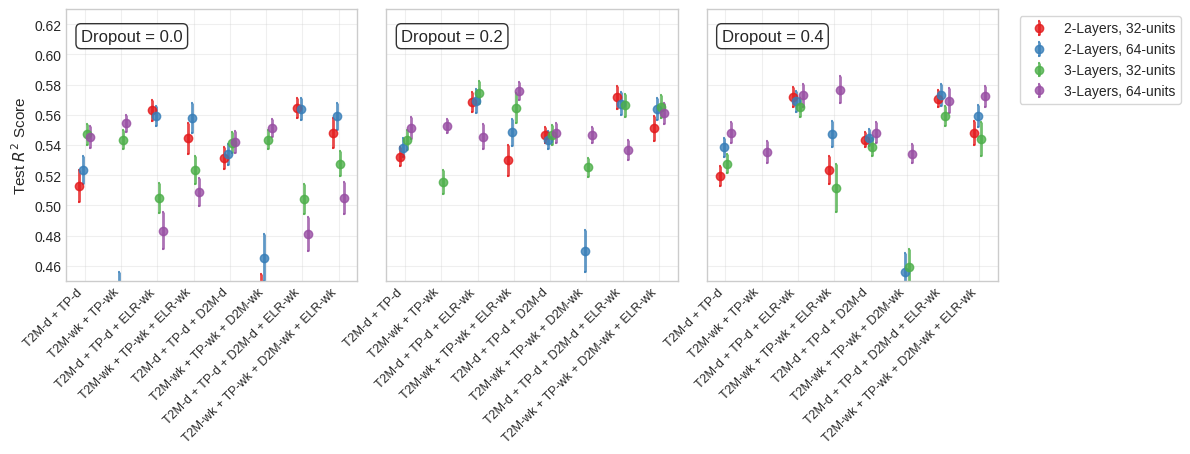

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 1) compute mean & SE per group
grp = (
    combined_df
    .groupby(['dropout','input_variables_clean','num_layers','hidden_dim'])
    .test_r2
    .agg(['mean','sem'])
    .reset_index()
)

# Filter to only include desired input variables
grp = grp[grp['input_variables_clean'].isin(desired_order)]

# 2) facet and plot with improvements
dropouts = sorted(grp['dropout'].unique())
ncol = len(dropouts)
fig, axes = plt.subplots(1, ncol, sharey=True, figsize=(4*ncol, 5))

# Professional color palette
colors = sns.color_palette("Set1", n_colors=4)

for ax, do in zip(axes, dropouts):
    sub = grp[grp['dropout']==do]
    
    # Get unique combinations for consistent coloring
    layer_dim_combos = list(sub.groupby(['num_layers','hidden_dim']).groups.keys())
    
    for i, ((layers, dim), sub2) in enumerate(sub.groupby(['num_layers','hidden_dim'])):
        # Sort sub2 according to desired order
        sub2['order'] = sub2['input_variables_clean'].map({v: i for i, v in enumerate(desired_order)})
        sub2 = sub2.sort_values('order')
        
        # Create x positions with displacement
        n_groups = len(layer_dim_combos)
        displacement = (i - (n_groups-1)/2) * 0.1
        x = np.arange(len(sub2)) + displacement
        
        # Plot with professional styling
        ax.errorbar(x, sub2['mean'], yerr=sub2['sem'],
                   fmt='o', 
                   color=colors[i % len(colors)],
                   label=f"{layers}-Layers, {dim}-units",
                   capsize=1,
                   capthick=1.5,
                   linewidth=2,
                   markersize=6,
                   alpha=0.8)
    
    # Get the ordered labels for x-axis
    ordered_labels = [label for label in desired_order if label in sub['input_variables_clean'].values]
    
    # Improve x-axis labels with LaTeX support
    ax.set_xticks(np.arange(len(ordered_labels)))
    ax.set_xticklabels(ordered_labels, rotation=45, ha='right', fontsize=9)
    ax.text(0.4, 0.9, f"Dropout = {do:.1f}", 
            transform=ax.transAxes, fontsize=12, ha='right', va='center', 
            bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white', alpha=0.8))
    ax.grid(True, alpha=0.3)
    #ax.set_xlabel('Input Variables', fontsize=11)
    
    # Only add y-label to the first subplot
    if do == dropouts[0]:
        ax.set_ylabel(r'Test $R^2$ Score', fontsize=11)

# Improve legend
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', 
              frameon=True, fancybox=True)
plt.ylim(0.45, 0.63)  # Set y-limits for better comparison
# Overall styling improvements
#fig.suptitle('Model Performance by Hidden Layers Configuration', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.9, wspace=0.1)  # Reduced spacing between plots
savefig = os.path.join("./", "./nn_results_by_dropout.pdf")
plt.savefig(savefig, bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
import pandas as pd

# 1) Compute summary statistics for each configuration
metrics = [
    'test_r2',
    'test_loss',
    'test_binary_accuracy',
    'test_rmse'
]
agg_funcs = {m: ['mean', 'sem'] for m in metrics}

summary_df = (
    combined_df
    .groupby(['input_variables_clean', 'dropout', 'num_layers', 'hidden_dim'])
    .agg(agg_funcs)
)

# 2) Flatten the MultiIndex columns
summary_df.columns = [
    '_'.join(col).strip() for col in summary_df.columns.values
]
summary_df = summary_df.reset_index()

# 3) (Optional) display the full summary
#display(summary_df)
# 4) Select the top 5 configurations by mean R²
top5 = summary_df.sort_values('test_r2_mean', ascending=False).head(5)
# 5) Display the top 5 configurations
display(top5)

,input_variables_clean,dropout,num_layers,hidden_dim,test_r2_end_mean,test_r2_end_sem,test_loss_end_mean,test_loss_end_sem,test_binary_accuracy_end_mean,test_binary_accuracy_end_sem,test_rmse_end_mean,test_rmse_end_sem
95,T2M-wk + TP-wk + ELR-wk,0.4,3,64,0.576481,0.008839,311.536295,86.930493,0.891702,0.004898,25.740348,0.696546
91,T2M-wk + TP-wk + ELR-wk,0.2,3,64,0.575555,0.006121,343.087998,94.212206,0.903119,0.003368,25.938063,0.617925
42,T2M-d + TP-d + ELR-wk,0.2,3,32,0.574582,0.007546,364.625443,97.799865,0.906144,0.003552,26.045403,0.591366
33,T2M-d + TP-d + D2M-d + ELR-wk,0.4,2,64,0.573347,0.007302,345.768807,92.727339,0.914350,0.001897,26.386047,0.525272
47,T2M-d + TP-d + ELR-wk,0.4,3,64,0.572861,0.007593,372.266611,99.952028,0.905205,0.004091,26.008102,0.539767


In [ ]:
import pandas as pd

# 1) Aggregate means & SEMs
metrics = [
    'test_r2',
    'test_loss',
    'test_binary_accuracy',
    'test_rmse',
]
agg_funcs = {m: ['mean', 'sem'] for m in metrics}

summary_df = (
    combined_df
      .groupby(['input_variables', 'dropout', 'num_layers', 'hidden_dim'])
      .agg(agg_funcs)
)

# flatten the MultiIndex cols
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
summary_df = summary_df.reset_index()

# 2) Pick top‐5 by mean R²
top5 = summary_df.sort_values('test_r2_mean', ascending=False).head(5)

# 3) Map Variables → compact LaTeX
latex_name_map = {
    # use exactly the strings that appear in input_variables_clean
    't2m_mean_znorm; tp_sum_znorm; d2m_mean_znorm; p1zn; p2zn':
        r'$T2M + TP + D2M + R_{t-1} + R_{t-2}$',
    't2m_mean_znorm(mean); tp_sum_znorm(mean); d2m_mean_znorm(mean); p1zn; p2zn':
        r'$T2M^{wk} + TP^{wk} + D2M^{wk} + R_{t-1} + R_{t-2}$',
    't2m_mean_znorm; tp_sum_znorm':
        r'$T2M + TP$',
    't2m_mean_znorm(mean); tp_sum_znorm(mean)':
        r'$T2M^{wk} + TP^{wk}$',
    't2m_mean_znorm; tp_sum_znorm; p1zn; p2zn':
        r'$T2M + TP + R_{t-1} + R_{t-2}$',
    't2m_mean_znorm(mean); tp_sum_znorm(mean); p1zn; p2zn':
        r'$T2M^{wk} + TP^{wk} + R_{t-1} + R_{t-2}$',
}

top5['Variables'] = top5['input_variables'].map(latex_name_map)

# 4) Define your formatter for mean ± SE
def fmt_mean_sem(mean, sem, sig_digits=2):
    """
    Format mean ± sem:
      - sem rounded to specified significant digits, no scientific notation
      - mean shown with matching decimals (fixed-point)
    """
    import math
    import numpy as np
    if sem == 0 or np.isnan(sem):
        return rf"${mean:.3f}\pm{sem:.2f}$"
    
    # Calculate decimals based on significant digits
    exp = int(math.floor(math.log10(abs(sem))))
    decimals = -exp + (sig_digits - 1)
    
    sem_rounded = round(sem, decimals)
    mean_rounded = round(mean, decimals)
    
    if decimals > 0:
        fmt = f"{{0:.{decimals}f}}"
        mean_str = fmt.format(mean_rounded)
        sem_str = fmt.format(sem_rounded)
    elif decimals == 0:
        mean_str = f"{int(round(mean_rounded))}"
        sem_str = f"{int(round(sem_rounded))}"
    else:
        # decimals < 0: round to 10s, 100s, etc.
        factor = 10**(-decimals)
        mean_str = f"{int(round(mean_rounded/factor)*factor)}"
        sem_str = f"{int(round(sem_rounded/factor)*factor)}"
    
    return rf"${mean_str}\pm{sem_str}$"

# 5) Build new "pm" columns
for metric, label in [
    ('test_r2',             'R^2'),
    ('test_loss',           'Loss'),
    ('test_binary_accuracy','Acc'),
    ('test_rmse',           'RMSE'),
]:
    m_mean = f"{metric}_mean"
    m_sem  = f"{metric}_sem"
    col_pm = f"{label}_pm"
    top5[col_pm] = top5.apply(
        lambda row: fmt_mean_sem(row[m_mean], row[m_sem]),
        axis=1
    )

# 6) Assemble the final table
final = top5[[
    'Variables', 'dropout', 'num_layers', 'hidden_dim',
    'R^2_pm', 'Loss_pm', 'Acc_pm', 'RMSE_pm'
]].rename(columns={
    'dropout':'Drop',
    'num_layers':'Lay',
    'hidden_dim':'HU',
    'R^2_pm':r'$R^2\pm SE$',
    'Loss_pm':r'$\overline{Loss}\pm SE$',
    'Acc_pm':r'$\overline{Acc}\pm SE$',
    'RMSE_pm':r'$\overline{RMSE}\pm SE$',
})

# 7) Set up formatting for the three numeric config columns
fmt = {
    'Drop': lambda x: f"{x:.2g}",
    'Lay':  lambda x: f"{int(x)}",
    'HU':   lambda x: f"{int(x)}",
}

# 8) Emit LaTeX
print(final.to_latex(
    index=False,
    escape=False,
    caption=r"Top 5 Model Configurations by Test $R^2$",
    label="tab:top5models",
    column_format='lrrr' + 'r'*(len(final.columns)-4),
    formatters=fmt
))


\begin{table}
\caption{Top 5 Model Configurations by Test $R^2$}
\label{tab:top5models}
\begin{tabular}{lrrrrrrr}
\toprule
Variables & Drop & Lay & HU & $R^2\pm SE$ & $\overline{Loss}\pm SE$ & $\overline{Acc}\pm SE$ & $\overline{RMSE}\pm SE$ \\
\midrule
$T2M^{wk} + TP^{wk} + R_{t-1} + R_{t-2}$ & 0.4 & 3 & 64 & $0.5765\pm0.0088$ & $312\pm87$ & $0.8917\pm0.0049$ & $25.74\pm0.70$ \\
$T2M^{wk} + TP^{wk} + R_{t-1} + R_{t-2}$ & 0.2 & 3 & 64 & $0.5756\pm0.0061$ & $343\pm94$ & $0.9031\pm0.0034$ & $25.94\pm0.62$ \\
$T2M + TP + R_{t-1} + R_{t-2}$ & 0.2 & 3 & 32 & $0.5746\pm0.0075$ & $365\pm98$ & $0.9061\pm0.0036$ & $26.05\pm0.59$ \\
NaN & 0.4 & 2 & 64 & $0.5733\pm0.0073$ & $346\pm93$ & $0.9144\pm0.0019$ & $26.39\pm0.53$ \\
$T2M + TP + R_{t-1} + R_{t-2}$ & 0.4 & 3 & 64 & $0.5729\pm0.0076$ & $372\pm100$ & $0.9052\pm0.0041$ & $26.01\pm0.54$ \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
# Get the best performing configuration (highest test_r2_mean)
best_config = summary_df.loc[summary_df['test_r2_mean'].idxmax()]

print("Best performing configuration:")
print(f"Input variables: {best_config['input_variables']}")
print(f"Dropout: {best_config['dropout']}")
print(f"Num layers: {best_config['num_layers']}")
print(f"Hidden dim: {best_config['hidden_dim']}")
print(f"Mean R²: {best_config['test_r2_mean']:.6f}")
print(f"SEM R²: {best_config['test_r2_sem']:.6f}")

# Filter combined_df to get all instances with this configuration
best_instances = combined_df[
    (combined_df['input_variables'] == best_config['input_variables']) &
    (combined_df['dropout'] == best_config['dropout']) &
    (combined_df['num_layers'] == best_config['num_layers']) &
    (combined_df['hidden_dim'] == best_config['hidden_dim'])
]

print(f"\nFound {len(best_instances)} instances with this configuration")

# Calculate absolute difference from mean for each instance
mean_r2 = best_config['test_r2_mean']
best_instances_copy = best_instances.copy()
best_instances_copy['abs_diff_from_mean'] = abs(best_instances_copy['test_r2'] - mean_r2)

# Find the random state closest to the mean
closest_to_mean = best_instances_copy.loc[best_instances_copy['abs_diff_from_mean'].idxmin()]

print(f"\nRandom state closest to mean:")
print(f"Random state: {closest_to_mean['random_state']}")
print(f"Test R²: {closest_to_mean['test_r2']:.6f}")
print(f"Difference from mean: {closest_to_mean['abs_diff_from_mean']:.6f}")

# Show all instances sorted by closeness to mean
print(f"\nAll instances sorted by closeness to mean:")
display(best_instances_copy[['random_state', 'test_r2', 'abs_diff_from_mean']].sort_values('abs_diff_from_mean'))

Best performing configuration:
Input variables: t2m_mean_znorm; tp_sum_znorm; d2m_mean_znorm; p1zn; p2zn
Dropout: 0.2
Num layers: 2
Hidden dim: 64
Mean R²: 0.609440
SEM R²: 0.008009

Found 10 instances with this configuration

Random state closest to mean:
Random state: 3
Test R²: 0.607035
Difference from mean: 0.002405

All instances sorted by closeness to mean:


,random_state,test_r2_end,abs_diff_from_mean
167,3,0.607035,0.002405
874,10,0.617963,0.008523
210,5,0.594854,0.014586
456,19,0.592627,0.016813
301,4,0.591316,0.018124
673,15,0.630835,0.021396
513,18,0.586448,0.022992
109,2,0.632583,0.023143
780,13,0.580934,0.028505
579,17,0.659802,0.050362


In [ ]:
best_instances_copy

,model_type,loss_type,hidden_dim,num_layers,dropout,num_epochs,learning_rate,batch_size,random_state,nonzero_weight,...,train_FPR_end,test_FPR_end,train_FNR_end,test_FNR_end,train_TPR_end,test_TPR_end,train_TNR_end,test_TNR_end,input_variables_clean,abs_diff_from_mean
109,positive_ff,FrequencyWeighted,64,2,0.2,1500,0.00005,64,2,0.799171,...,0.061696,0.091717,0.172451,0.179024,0.827549,0.820976,0.938304,0.908283,T2M-d + TP-d + D2M-d + ELR-wk,0.023143
167,positive_ff,FrequencyWeighted,64,2,0.2,1500,0.00005,64,3,0.799415,...,0.065457,0.084146,0.203524,0.265534,0.796476,0.734466,0.934543,0.915854,T2M-d + TP-d + D2M-d + ELR-wk,0.002405
210,positive_ff,FrequencyWeighted,64,2,0.2,1500,0.00005,64,5,0.799415,...,0.068384,0.072805,0.191495,0.228641,0.808505,0.771359,0.931616,0.927195,T2M-d + TP-d + D2M-d + ELR-wk,0.014586
301,positive_ff,FrequencyWeighted,64,2,0.2,1500,0.00005,64,4,0.799659,...,0.067297,0.066911,0.171168,0.194203,0.828832,0.805797,0.932703,0.933089,T2M-d + TP-d + D2M-d + ELR-wk,0.018124
456,positive_ff,FrequencyWeighted,64,2,0.2,1500,0.00005,64,19,0.799659,...,0.072996,0.083150,0.186983,0.181643,0.813017,0.818357,0.927004,0.916850,T2M-d + TP-d + D2M-d + ELR-wk,0.016813
513,positive_ff,FrequencyWeighted,64,2,0.2,1500,0.00005,64,18,0.799171,...,0.060537,0.069428,0.197209,0.225854,0.802791,0.774146,0.939463,0.930572,T2M-d + TP-d + D2M-d + ELR-wk,0.022992
579,positive_ff,FrequencyWeighted,64,2,0.2,1500,0.00005,64,17,0.799415,...,0.076982,0.082561,0.146537,0.169417,0.853463,0.830583,0.923018,0.917439,T2M-d + TP-d + D2M-d + ELR-wk,0.050362
673,positive_ff,FrequencyWeighted,64,2,0.2,1500,0.00005,64,15,0.799415,...,0.063841,0.075488,0.182503,0.235437,0.817497,0.764563,0.936159,0.924512,T2M-d + TP-d + D2M-d + ELR-wk,0.021396
780,positive_ff,FrequencyWeighted,64,2,0.2,1500,0.00005,64,13,0.799171,...,0.061848,0.063459,0.185558,0.266829,0.814442,0.733171,0.938152,0.936541,T2M-d + TP-d + D2M-d + ELR-wk,0.028505
874,positive_ff,FrequencyWeighted,64,2,0.2,1500,0.00005,64,10,0.799415,...,0.062134,0.062439,0.186999,0.241262,0.813001,0.758738,0.937866,0.937561,T2M-d + TP-d + D2M-d + ELR-wk,0.008523


In [ ]:
import glob

# Get the best performing configuration from your previous analysis
best_config = summary_df.loc[summary_df['test_r2_mean'].idxmax()]

# Extract the parameters
model_type = "positive_ff"  # From your data
loss_type = "FrequencyWeighted"  # From your data
hidden_dim = int(best_config['hidden_dim'])
num_layers = int(best_config['num_layers'])
dropout = best_config['dropout']
learning_rate = "5e-05"  # From your data (appears to be consistent)
batch_size = 64  # From your data (appears to be consistent)
random_state = closest_to_mean['random_state']  # You'll need to specify which random state you want
input_variables = best_config['input_variables']

# Clean the input_variables string to match filename format
# Replace special characters and spaces that might be in filenames
input_vars_clean = input_variables.replace(';', '+').replace(' ', '').replace('(', '').replace(')', '').replace(',', '')

# Construct the filename
filename = f"modelpositive_ff_lossFrequencyWeighted_hid{hidden_dim}_lay{num_layers}_do{dropout}_lr{learning_rate}_bs{batch_size}_sd{random_state}_{input_vars_clean}_results.pkl"

print("Best configuration parameters:")
print(f"Hidden dim: {hidden_dim}")
print(f"Num layers: {num_layers}")
print(f"Dropout: {dropout}")
print(f"Input variables: {input_variables}")
print(f"\nConstructed filename:")
print(filename)

# Full path to the file
results_folder = "./MSE/"
full_path = os.path.join(results_folder, filename)
print(f"\nFull path:")
print(full_path)

# Check if file exists
if os.path.exists(full_path):
    print(f"\n✓ File exists!")
else:
    print(f"\n✗ File not found. You may need to adjust the filename format.")
    # Let's also try to find similar files
    pattern = f"modelpositive_ff_lossFrequencyWeighted_hid{hidden_dim}_lay{num_layers}_do{dropout}*.pkl"
    similar_files = glob.glob(os.path.join(results_folder, pattern))
    if similar_files:
        print("Similar files found:")
        for f in similar_files:
            print(f"  {os.path.basename(f)}")

Best configuration parameters:
Hidden dim: 64
Num layers: 2
Dropout: 0.2
Input variables: t2m_mean_znorm; tp_sum_znorm; d2m_mean_znorm; p1zn; p2zn

Constructed filename:
modelpositive_ff_lossFrequencyWeighted_hid64_lay2_do0.2_lr5e-05_bs64_sd3_t2m_mean_znorm+tp_sum_znorm+d2m_mean_znorm+p1zn+p2zn_results.pkl

Full path:
./MSE/modelpositive_ff_lossFrequencyWeighted_hid64_lay2_do0.2_lr5e-05_bs64_sd3_t2m_mean_znorm+tp_sum_znorm+d2m_mean_znorm+p1zn+p2zn_results.pkl

✗ File not found. You may need to adjust the filename format.


In [ ]:
import pandas as pd

# --- 1) Aggregate means & SEMs ---
metrics = [
    'test_r2',
    'test_loss',
    'test_binary_accuracy',
    'test_rmse',
]
agg_funcs = {m: ['mean', 'sem'] for m in metrics}

summary_df = (
    combined_df
      .groupby(['input_variables_clean', 'dropout', 'num_layers', 'hidden_dim'])
      .agg(agg_funcs)
)

# flatten the MultiIndex cols
summary_df.columns = ['_'.join(col).strip() for col in summary_df.columns.values]
summary_df = summary_df.reset_index()

# --- 2) Pick top-5 by mean R² ---
top5 = summary_df.sort_values('test_r2_mean', ascending=False).head(5)

# --- 3) Rename for LaTeX (all math wrapped in $…$!) ---
latex_cols = {
    'input_variables_clean': 'Variables',
    'dropout':             'Dropout',
    'num_layers':          'Layers',
    'hidden_dim':          'Hidden Units',
    'test_r2_mean':    r'$\overline{R^2}$',
    'test_r2_sem':     r'$SE(R^2)$',
    'test_loss_mean':  r'$\overline{Loss}$',
    'test_loss_sem':   r'$SE(Loss)$',
    'test_binary_accuracy_mean': r'$\overline{Acc}$',
    'test_binary_accuracy_sem':  r'$SE(Acc)$',
    'test_rmse_mean':  r'$\overline{RMSE}$',
    'test_rmse_sem':   r'$SE(RMSE)$',
}
top5 = top5.rename(columns=latex_cols)

# --- 4) Print the LaTeX table ---
print(top5.to_latex(
    index=False,
    float_format="%.3f",
    caption=r"Top 5 Model Configurations by Test $R^2$",
    label="tab:top5models",       # no underscore here
    escape=False,                  # preserve our $…$’s
    column_format='l' + 'r'*(len(top5.columns)-1)
))

# In your .tex preamble make sure you have:
#   \usepackage{booktabs}
#   \usepackage{amsmath}


\begin{table}
\caption{Top 5 Model Configurations by Test $R^2$}
\label{tab:top5models}
\begin{tabular}{lrrrrrrrrrrr}
\toprule
Variables & Dropout & Layers & Hidden Units & $\overline{R^2}$ & $SE(R^2)$ & $\overline{Loss}$ & $SE(Loss)$ & $\overline{Acc}$ & $SE(Acc)$ & $\overline{RMSE}$ & $SE(RMSE)$ \\
\midrule
T2M-d + TP-d + D2M-d + ELR-wk & 0.200 & 2 & 64 & 0.609 & 0.008 & 910.863 & 53.082 & 0.896 & 0.002 & 25.056 & 0.710 \\
T2M-d + TP-d + D2M-d + ELR-wk & 0.000 & 2 & 64 & 0.608 & 0.008 & 910.881 & 47.974 & 0.884 & 0.003 & 25.073 & 0.626 \\
T2M-d + TP-d + ELR-wk & 0.100 & 2 & 64 & 0.608 & 0.009 & 883.246 & 73.534 & 0.882 & 0.004 & 24.522 & 0.963 \\
T2M-wk + TP-wk + ELR-wk & 0.200 & 3 & 32 & 0.608 & 0.012 & 932.781 & 92.186 & 0.853 & 0.004 & 24.677 & 1.153 \\
T2M-d + TP-d + ELR-wk & 0.000 & 2 & 64 & 0.606 & 0.008 & 873.639 & 62.532 & 0.873 & 0.003 & 24.458 & 0.840 \\
\bottomrule
\end{tabular}
\end{table}

